In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import textwrap
import pandas as pd
import matplotlib.lines as mlines

C:\Users\91880\AppData\Local\Temp\ipykernel_53300\2226650730.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
papers_recent = ["JSSC'25","JSSC'22","JSSC'22","JSSC'23","ISSCC'21","TCAS1'24","JSSC'24"]
reference_id_recent = [1,2,2,3,4,6,7]
Info_Defi_recent = [6.66,2,6,1,2.2,8.7,1]
EE_recent = [643.2,15.8,490,1508,1936,1050.6,1829]
tech_recent = [65,65,65,28,16,22,28]


In [3]:
df = pd.read_csv("d:\ISSCC_26\Benchmarking_Data.csv")

# Show first 5 rows

filtered_df = df[df["Year"] > 2020]
filtered_df = filtered_df[filtered_df["Architecture"] == "SRAM"]
filtered_df = filtered_df[filtered_df["TOPS/W"] < 1500]
filtered_df = filtered_df[(filtered_df["B_pre-ADC"] - filtered_df["B_ADC"]) < 9]
filtered_df = filtered_df[(filtered_df["B_pre-ADC"] - filtered_df["B_ADC"]) > -1]
#filtered_df = filtered_df[filtered_df["B_ADC"] < 11]
B_ADC = filtered_df["B_ADC"].to_numpy()
BI_COL = filtered_df["B_pre-ADC"].to_numpy()
EE = filtered_df["TOPS/W"].to_numpy()
tech = filtered_df["Tech (nm)"].to_numpy()
paper_name = filtered_df["Journal/Conference"].to_numpy()
paper_year = filtered_df["Year"].to_numpy()
paper_title = filtered_df["Paper Title"].to_numpy()
paper_author = filtered_df["Authors"].to_numpy()

papers = [str(paper_name[i])+"'" + str(paper_year[i]) for i in range(len(paper_name))]
papers = np.array(papers)
Info_Defi = BI_COL-B_ADC
mask = ~np.isnan(B_ADC)

paper_name = paper_name[mask]
paper_year = paper_year[mask]
paper_title = paper_title[mask]
paper_author = paper_author[mask]

Info_Defi = np.concatenate((Info_Defi[mask],Info_Defi_recent))
EE = np.concatenate((EE[mask],EE_recent))
tech = np.concatenate((tech[mask],tech_recent))
reference_id = np.arange(8,len(papers[mask])+8)
papers = np.concatenate((papers[mask],papers_recent))
reference_id = np.concatenate((reference_id,reference_id_recent))
marker_map = {28: "*", 65: "d", 45: "^",22:"o",16:"p"}
marker_array = np.array([marker_map[c] for c in tech])
print(filtered_df["Index"])
print(reference_id)


51    76
54    78
68    24
70    46
76    36
77    37
Name: Index, dtype: int64
[ 8  9 10 11 12 13  1  2  2  3  4  6  7]


In [4]:
title = []
for i in range(len(paper_name)):
    text = ""
    text += "[" + str(reference_id[i])+ "] " + str(paper_author[i]) + ', "' + str(paper_title[i]) + '," ' + str(paper_name[i]) + " " + str(paper_year[i])
    title.append(text)
    print(text)

[8] Avishek Biswas et al., "An area-efficient 6T-SRAM based Compute-In-Memory architecture with reconfigurable SAR ADCs for energy efficient deep neural networks in edge ML applications," CICC 2022
[9] Zhiyu Chen et al., "DCT-RAM: A Driver-Free Process-In-Memory 8T SRAM Macro with Multi-Bit Charge-Domain Computation and Time-Domain Quantization," CICC 2022
[10] Jinshan Yue et al., "A 2.75-to-75.9TOPS/W Computing-in-Memory NN Processor Supporting Set-Associate Block-Wise Zero Skipping and Ping-Pong CIM with Simultaneous Computation and Weight Updating," ISSCC  2021
[11] Ruiqi Guo et al., "A 5.99-to-691.1TOPS/W Tensor-Train In-Memory-Computing Processor Using Bit-Level-Sparsity-Based Optimization and Variable-Precision Quantization," ISSCC 2021
[12] Shihui Yin et al., "PIMCA: A 3.4-Mb Programmable In-Memory Computing Accelerator in 28nm for On-Chip DNN Inference," VLSI Circuits 2021
[13] Ruiqi Guo et al., "A 6.54-to-26.03 TOPS/W Computing-In-Memory RNN Processor using Input Similarity Op

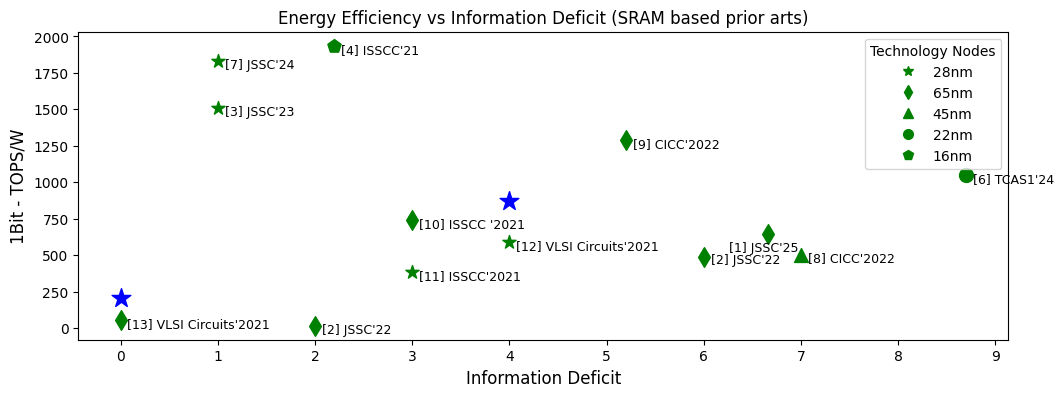

In [5]:
plt.figure(figsize=(12,4))
for i in range(len(Info_Defi)):
    if reference_id[i] == 1 :
        plt.scatter(Info_Defi[i],EE[i],marker=marker_array[i],s = 100, color = "g")
        text = "["+str(reference_id[i]) + "] " + str(papers[i])
        plt.text(Info_Defi[i] - 0.4, EE[i] - 120,text, fontsize=9, color="black")
    else:
        plt.scatter(Info_Defi[i],EE[i],marker=marker_array[i],s = 100, color = "g")
        text = "["+str(reference_id[i]) + "] " + str(papers[i])
        plt.text(Info_Defi[i] + 0.07, EE[i] - 50,text, fontsize=9, color="black")
plt.scatter([0,4],[208,873],marker = '*',s=200,color="b")
handles = [
    mlines.Line2D([], [], color="green", marker=m, linestyle="None",
                  markersize=7, label=str(k)+"nm")
    for k, m in marker_map.items()
]

plt.legend(handles=handles, title="Technology Nodes",loc = "best")
plt.title('Energy Efficiency vs Information Deficit (SRAM based prior arts)',fontsize=12)
plt.ylabel('1Bit - TOPS/W',fontsize=12)
plt.xlabel('Information Deficit',fontsize=12)
plt.xticks(np.arange(0, 10, 1))
#plt.savefig("D:\ISSCC_26\Graphs\comparison.jpg",dpi=400, bbox_inches="tight", transparent=True)
#plt.savefig("D:\ISSCC_26\Graphs\comparison.svg",format = "svg", bbox_inches="tight",transparent=True)
plt.show()

In [6]:
df_write = pd.DataFrame({
    "Title" : title,
    "Deficit" : Info_Defi[:6],
    "Efficiency" : EE[:6]
})
print(df_write)

                                               Title  Deficit  Efficiency
0  [8] Avishek Biswas et al., "An area-efficient ...      7.0      504.00
1  [9] Zhiyu Chen et al., "DCT-RAM: A Driver-Free...      5.2     1288.00
2  [10] Jinshan Yue et al., "A 2.75-to-75.9TOPS/W...      3.0      740.00
3  [11] Ruiqi Guo et al., "A 5.99-to-691.1TOPS/W ...      3.0      383.68
4  [12] Shihui Yin et al., "PIMCA: A 3.4-Mb Progr...      4.0      588.00
5  [13] Ruiqi Guo et al., "A 6.54-to-26.03 TOPS/W...      0.0       52.06


In [7]:
print(EE)
EE_Scaled = [EE[i] * (float(tech[i])*float(tech[i]))/(28*28) for i in range(len(EE))]
print(EE_Scaled)

[ 504.   1288.    740.    383.68  588.     52.06  643.2    15.8   490.
 1508.   1936.   1050.6  1829.  ]
[1301.7857142857142, 6941.071428571428, 3987.8826530612246, 383.68, 588.0, 280.5529336734694, 3466.2244897959185, 85.14668367346938, 2640.625, 1508.0, 632.1632653061224, 648.584693877551, 1829.0]


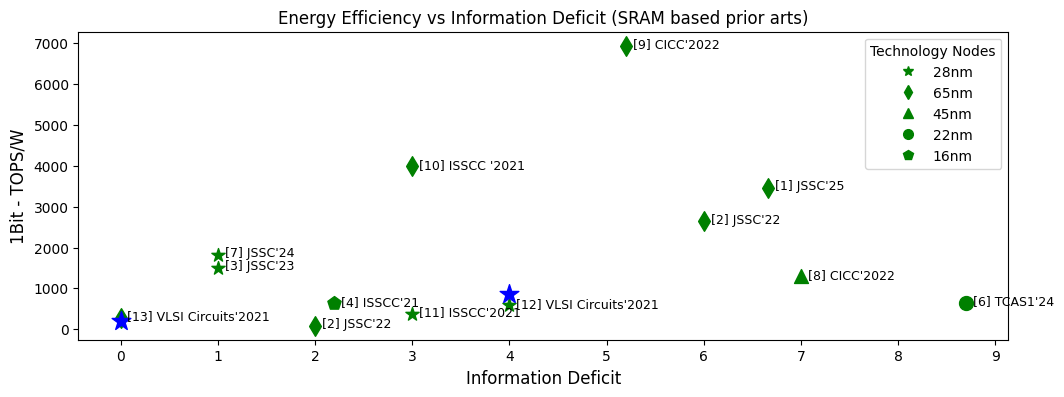

In [8]:
plt.figure(figsize=(12,4))
for i in range(len(Info_Defi)):
    plt.scatter(Info_Defi[i],EE_Scaled[i],marker=marker_array[i],s = 100, color = "g")
    text = "["+str(reference_id[i]) + "] " + str(papers[i])
    plt.text(Info_Defi[i] + 0.07, EE_Scaled[i] - 50,text, fontsize=9, color="black")
plt.scatter([0,4],[208,873],marker = '*',s=200,color="b")
handles = [
    mlines.Line2D([], [], color="green", marker=m, linestyle="None",
                  markersize=7, label=str(k)+"nm")
    for k, m in marker_map.items()
]

plt.legend(handles=handles, title="Technology Nodes",loc = "best")
plt.title('Energy Efficiency vs Information Deficit (SRAM based prior arts)',fontsize=12)
plt.ylabel('1Bit - TOPS/W',fontsize=12)
plt.xlabel('Information Deficit',fontsize=12)
plt.xticks(np.arange(0, 10, 1))
#plt.savefig("D:\ISSCC_26\Graphs\comparison.jpg",dpi=400, bbox_inches="tight", transparent=True)
#plt.savefig("D:\ISSCC_26\Graphs\comparison.svg",format = "svg", bbox_inches="tight",transparent=True)
plt.show()

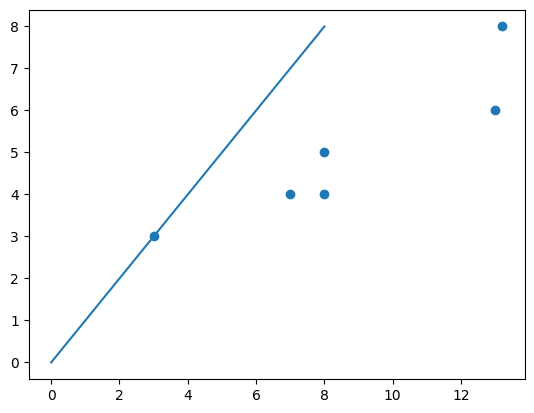

In [9]:
x_axis = np.arange(0,9)
plt.scatter(BI_COL,B_ADC)
plt.plot(x_axis)

In [10]:
df_final = pd.read_excel(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\references.xlsx")
df_final

,Ref_ID,Title,Deficit,EE,Tech,Tag
0,1,"[1] Jie Lou et al., “An Energy Efficient All-D...",8.70,1050.60,22,TCAS-1'24
1,2,"[2] Avishek Biswas et al., ""An area-efficient ...",7.00,504.00,45,CICC'22
2,3,"[3] Zhiyu Chen et al., “PICO-RAM: A PVT-Insens...",6.66,643.20,65,JSSC'25
3,4,"[4] Chengshuo Yu et al., “A 65-nm 8T SRAM Comp...",6.00,490.00,65,JSSC'22
4,4,"[4] Chengshuo Yu et al., “A 65-nm 8T SRAM Comp...",2.00,15.80,65,JSSC'22
5,5,"[5] Zhiyu Chen et al., ""DCT-RAM: A Driver-Free...",5.20,1288.00,65,CICC'22
6,6,"[6] Shihui Yin et al., ""PIMCA: A 3.4-Mb Progra...",4.00,588.00,28,VLSI Circuits'21
7,7,"[7] Jinshan Yue et al., ""A 2.75-to-75.9TOPS/W ...",3.00,740.00,65,ISSCC'21
8,8,"[8] Ruiqi Guo et al., ""A 5.99-to-691.1TOPS/W T...",3.00,383.68,28,ISSCC'21
9,11,"[11] Hongyang Jia et al., “A Programmable Neur...",2.20,1936.00,16,ISSCC'21


In [26]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 12

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 11

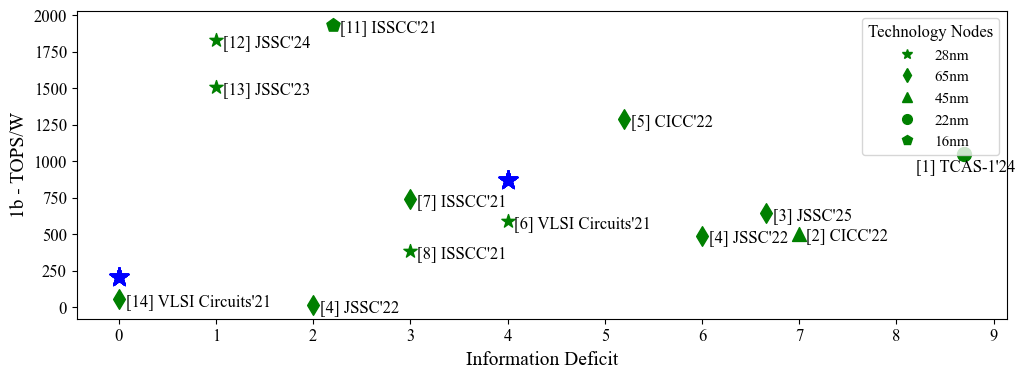

In [27]:
plt.figure(figsize=(12,4))
marker_map = {28: "*", 65: "d", 45: "^",22:"o",16:"p"}
marker_array = np.array([marker_map[c] for c in df_final["Tech"]])
for i in range(len(Info_Defi)):
    if df_final["Ref_ID"][i] == 1:
        plt.scatter(df_final["Deficit"][i],df_final["EE"][i],marker=marker_array[i],s = 100, color = "g")
        text = "["+str(df_final["Ref_ID"][i]) + "] " + str(df_final['Tag'][i])
        plt.text(df_final["Deficit"][i] - 0.5, df_final["EE"][i] - 120,text, fontsize=12, color="black")
    else:
        plt.scatter(df_final["Deficit"][i],df_final["EE"][i],marker=marker_array[i],s = 100, color = "g")
        text = "["+str(df_final["Ref_ID"][i]) + "] " + str(df_final['Tag'][i])
        plt.text(df_final["Deficit"][i] + 0.07, df_final["EE"][i] - 50,text, fontsize=12, color="black")
    plt.scatter([0,4],[208,873],marker = '*',s=200,color="b")
handles = [
    mlines.Line2D([], [], color="green", marker=m, linestyle="None",
                  markersize=7, label=str(k)+"nm")
    for k, m in marker_map.items()
]

plt.legend(handles=handles, title="Technology Nodes",loc = "upper right")
#plt.title('Energy Efficiency vs Information Deficit (SRAM based prior arts)',fontsize=15)
plt.ylabel('1b - TOPS/W',fontsize=14)
plt.xlabel('Information Deficit',fontsize=14)
plt.xticks(np.arange(0, 10, 1))
#plt.savefig("D:\ISSCC_26\Graphs\comparison.jpg",dpi=400, bbox_inches="tight", transparent=True)
plt.savefig("D:\ISSCC_26\Graphs\comparison.svg",format = "svg", bbox_inches="tight",transparent=True)
plt.show()